In [18]:
import pyarrow.feather as feather
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from item_classifier import *
from plots import *

In [19]:
table = feather.read_table('../dataset/data_andre.feather', memory_map=True) 
df= table.to_pandas() 
df.head()

,date,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
0,2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
1,2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,1,0.0,6269
2,2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
3,2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.1228,0,0.0,0,0.0,0,0.0,0,0.0,6269
4,2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


In [20]:
df_indexed = df.copy()
df_indexed["date"] = pd.to_datetime(df_indexed["date"])
df_indexed = df_indexed.set_index("date").sort_index()
df_indexed.head()

,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,1,0.0,6269
2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.1228,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


In [21]:
'''
# Classify all items
df_classified, summary = classify_items(
    df_indexed,
    seasonal_strength_threshold=0.3,    # Adjust based on your domain
    cv_threshold=0.5,                    # Adjust for intermittence detection
    initial_gap_fraction=0.2,            # 20% gap at start = new item
)

# Display summary
print("Label Distribution:")
print(summary['label_counts'])
print("\n" + "="*60)

df_classified.head()
'''


'\n# Classify all items\ndf_classified, summary = classify_items(\n    df_indexed,\n    seasonal_strength_threshold=0.3,    # Adjust based on your domain\n    cv_threshold=0.5,                    # Adjust for intermittence detection\n    initial_gap_fraction=0.2,            # 20% gap at start = new item\n)\n\n# Display summary\nprint("Label Distribution:")\nprint(summary[\'label_counts\'])\nprint("\n" + "="*60)\n\ndf_classified.head()\n'


## Classification Parameters Guide

The classifier uses three main parameters to categorize items:

### 1. `seasonal_strength_threshold` (default: 0.3)
- **What**: Strength of periodicity/seasonality in sales pattern (0-1 scale)
- **Higher values**: More strict seasonality detection
- **Lower values**: Easier to detect seasonal patterns
- **From document**: Items with sales/non-sales cycles that are regular and periodic

### 2. `cv_threshold` (default: 0.5)  
- **What**: Coefficient of Variation in cycle intervals
- **Higher values**: Allow more variability in intervals (more "erratic")
- **Lower values**: Stricter intermittence detection
- **From document**: Intermittent items have intervals that "don't share any common pattern"

### 3. `initial_gap_fraction` (default: 0.2)
- **What**: Fraction of zero-sales at the beginning (0-1 scale)
- **Higher values**: Allow longer initial gaps
- **Lower values**: Stricter new item detection
- **From document**: New items have "meaningful non-sales cycle at the beginning"

## Tuning Tips
- Start with defaults, then adjust based on your visualization results
- If too many items are "seasonal" → increase `seasonal_strength_threshold`
- If too many items are "intermittent" → increase `cv_threshold`
- If too many items are "new" → increase `initial_gap_fraction`


In [22]:
#plot_label_distribution(summary["label_counts"]);

In [23]:
df_classified, labels_df, summary = classify_items_adi_cv(df_indexed)


In [24]:
df_indexed.head()

,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,1,0.0,6269
2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.1228,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


In [25]:
df_classified

,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id,item_label
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,1,0.0,6269,seasonal
2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-22,29254,5,hot cereal,pos subd grocery other,pos dept grocery,breakfast,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
2023-02-22,29351,6,hot cereal,pos subd grocery other,pos dept grocery,breakfast,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
2023-02-22,506815,21,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0,0.0,1,0.0,0,0.0,0,0.0,6269,seasonal



Detailed Classification Distribution:
Total items: 1427

Breakdown:
  seasonal    :    929 items ( 65.1%)
  lumpy       :    428 items ( 30.0%)
  smooth      :     67 items (  4.7%)
  intermittent:      3 items (  0.2%)


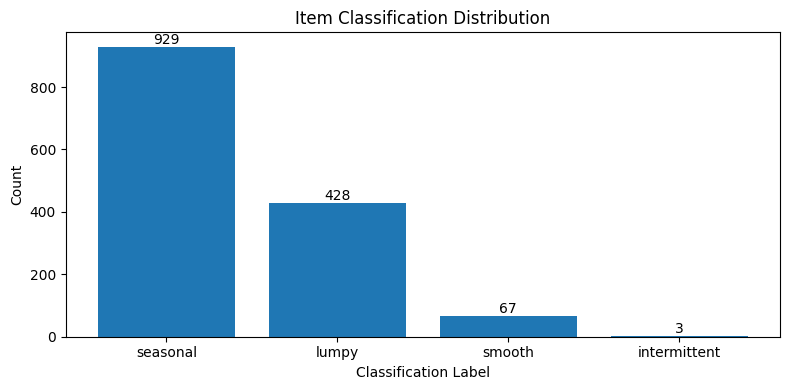

In [26]:
plot_label_distribution(summary['label_counts']);

Product ID: 151825
Date range: 2021-01-23 00:00:00 to 2022-08-14 00:00:00
Total records: 569
Non-zero sales: 550


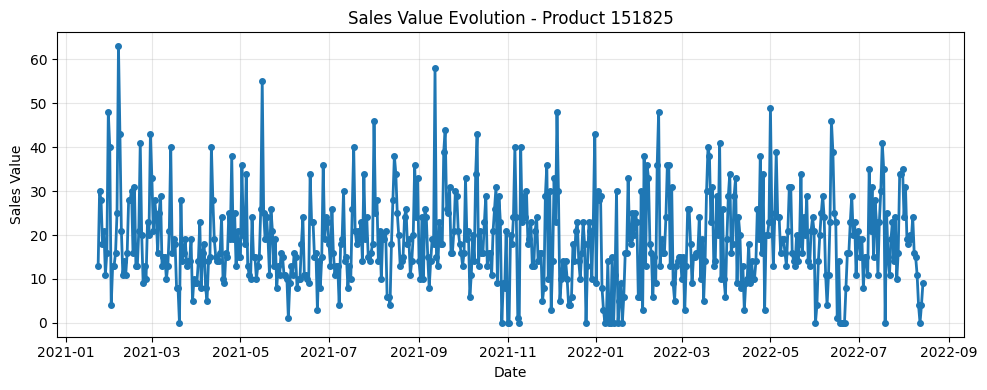

(<Axes: title={'center': 'Sales Value Evolution - Product 151825'}, xlabel='Date', ylabel='Sales Value'>,
           date  value
 0   2021-01-23     13
 1   2021-01-24     30
 2   2021-01-25     28
 3   2021-01-26     18
 4   2021-01-27     21
 ..         ...    ...
 564 2022-08-10     11
 565 2022-08-11      4
 566 2022-08-12      0
 567 2022-08-13      4
 568 2022-08-14      9
 
 [569 rows x 2 columns],
 {'product_id': 151825,
  'date_min': Timestamp('2021-01-23 00:00:00'),
  'date_max': Timestamp('2022-08-14 00:00:00'),
  'total_records': 569,
  'non_zero_sales': 550,
  'describe': count    569.000000
  mean      18.629174
  std       10.207077
  min        0.000000
  25%       13.000000
  50%       16.000000
  75%       24.000000
  max       63.000000
  Name: value, dtype: float64})

In [27]:
plot_product_value_evolution(df_indexed, selected_product=151825, date_col=None, value_col='value')


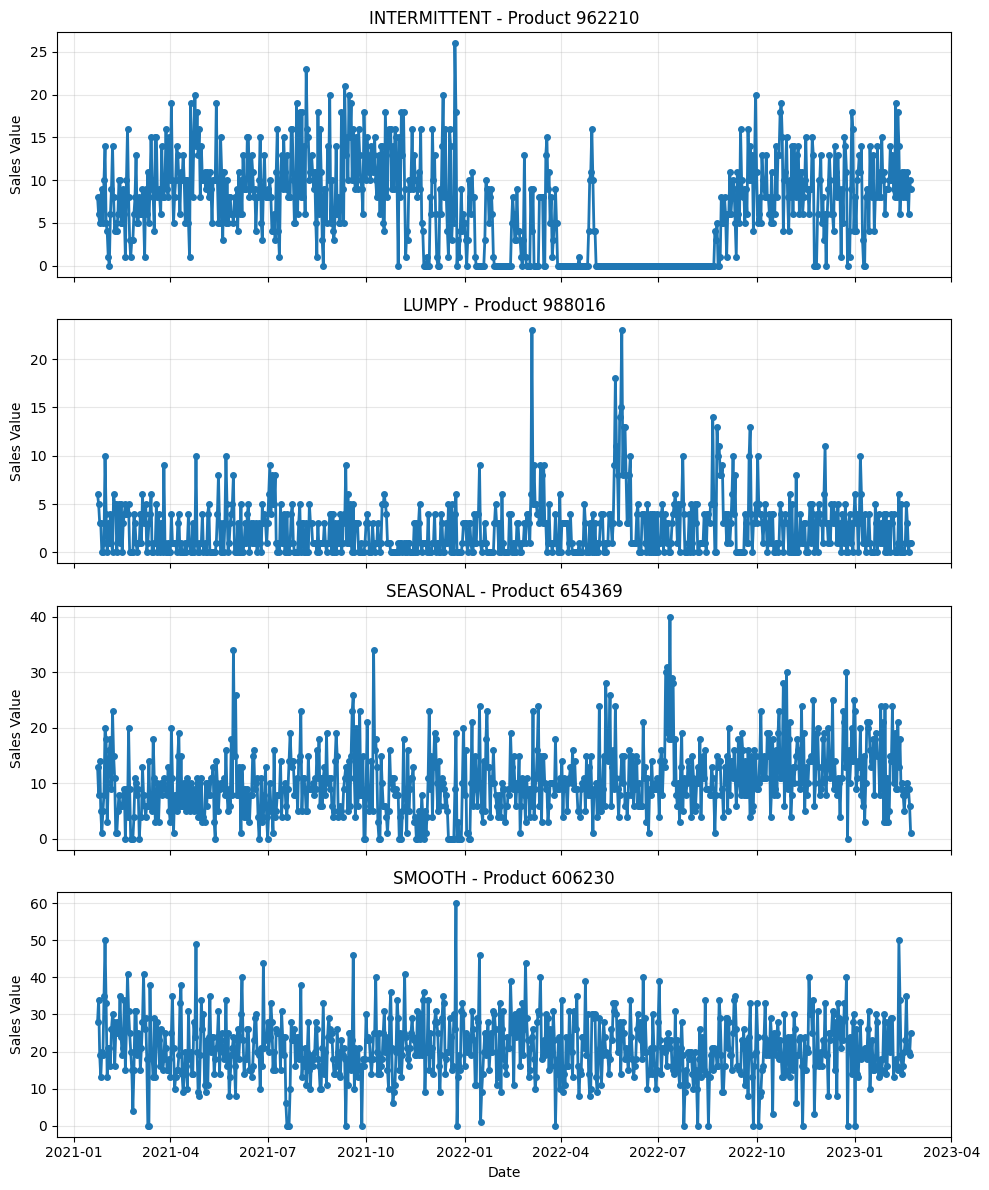

In [28]:
plot_random_sample_per_label(df_indexed, df_classified, date_col=None, seed=None);

In [29]:
df_classified[(df_classified['item_label']=='seasonal') | (df_classified['item_label']=='smooth')]

,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id,item_label
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,1,0.0,6269,seasonal
2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-22,29254,5,hot cereal,pos subd grocery other,pos dept grocery,breakfast,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
2023-02-22,29351,6,hot cereal,pos subd grocery other,pos dept grocery,breakfast,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,seasonal
2023-02-22,506815,21,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0,0.0,1,0.0,0,0.0,0,0.0,6269,seasonal


In [30]:
def select_best_seasonal_smooth(df, top_n=100, max_zero_rate=0.2, sales_col='value', item_col='item_id', label_col='item_label', labels=('seasonal','smooth'), by='total_sales'):
    # filter seasonal / smooth
    df_sub = df[df[label_col].isin(labels)].copy()

    # ensure numeric sales
    df_sub[sales_col] = pd.to_numeric(df_sub[sales_col], errors='coerce').fillna(0)

    # compute metrics per item
    agg = df_sub.groupby(item_col).agg(
        days_observed=('date', 'nunique'),
        total_sales=(sales_col, 'sum'),
        mean_sales=(sales_col, 'mean'),
        median_sales=(sales_col, 'median'),
        zeros=(sales_col, lambda x: (x==0).sum()),
        obs_count=(sales_col, 'count')
    ).reset_index()

    agg['zero_rate'] = agg['zeros'] / agg['obs_count']
    agg['nonzero_mean'] = agg.apply(lambda r: r['total_sales'] / max(1, r['obs_count'] - r['zeros']), axis=1)

    # filter by zero rate
    agg = agg[agg['zero_rate'] <= max_zero_rate]

    # choose sort key
    if by == 'total_sales':
        agg = agg.sort_values('total_sales', ascending=False)
    elif by == 'mean_sales':
        agg = agg.sort_values('mean_sales', ascending=False)
    elif by == 'nonzero_mean':
        agg = agg.sort_values('nonzero_mean', ascending=False)
    else:
        raise ValueError("by must be 'total_sales', 'mean_sales' or 'nonzero_mean'")

    # take top_n items and return original rows for those items
    top_items = agg.head(top_n)[item_col].tolist()
    return df_sub[df_sub[item_col].isin(top_items)].copy(), agg.loc[agg[item_col].isin(top_items)]

# Example usage:
# subset_rows, top_summary = select_best_seasonal_smooth(df_classified, top_n=50, max_zero_rate=0.15)

In [31]:
# Show a few example products for each ADI-CV category
n_examples = 5
for cat in ["smooth", "seasonal", "intermittent", "lumpy"]:
    items_in_cat = labels_df.loc[labels_df["label"] == cat].sort_values("total_periods", ascending=False)
    print(f"\n=== {cat.upper()} ({len(items_in_cat)} items) ===")
    display(items_in_cat.head(n_examples))



=== SMOOTH (67 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
7,606214,smooth,1.013316,0.352013,751,761
1112,213642,smooth,1.028378,0.449599,740,761
847,904556,smooth,1.070323,0.444356,711,761
894,907967,smooth,1.014667,0.339982,750,761
899,151815,smooth,1.007947,0.484090,755,761



=== SEASONAL (929 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
0,27,seasonal,1.007947,0.503782,755,761
793,6032,seasonal,1.006614,0.714684,756,761
780,161368,seasonal,1.318891,0.679772,577,761
782,901487,seasonal,1.298635,0.746489,586,761
784,84053,seasonal,1.087143,0.648222,700,761



=== INTERMITTENT (3 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
127,962210,intermittent,1.346903,0.477352,565,761
282,100472,intermittent,1.330420,0.487153,572,761
425,26910,intermittent,1.376130,0.376928,553,761



=== LUMPY (428 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
1210,917326,lumpy,1.404059,0.840637,542,761
442,113619,lumpy,1.427767,0.553275,533,761
595,298441,lumpy,1.323478,0.511543,575,761
599,25192,lumpy,1.438563,0.749105,529,761
605,117955,lumpy,1.503953,0.629500,506,761


In [32]:
# Export item_id -> ADI/CV label (smooth / seasonal / intermittent / lumpy) to CSV
df_labels_adi_cv = (
    labels_df[["item_id", "label"]]
    .drop_duplicates(subset="item_id")
    .sort_values("item_id")
    .reset_index(drop=True)
)

out_path = "../dataset/df_labels_adi_cv.csv"
df_labels_adi_cv.to_csv(out_path, index=False)
print(f"Saved {len(df_labels_adi_cv)} rows -> {out_path}")
print(df_labels_adi_cv["label"].value_counts())
df_labels_adi_cv.head()


Saved 1427 rows -> ../dataset/df_labels_adi_cv.csv
label
seasonal        929
lumpy           428
smooth           67
intermittent      3
Name: count, dtype: int64


,item_id,label
0,27,seasonal
1,55,lumpy
2,71,seasonal
3,116,smooth
4,128,seasonal
